In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [14]:
df = pd.read_csv("/content/insurance_claims_dataset.csv")

In [15]:
df.head(10)

,Claim_ID,Age,Gender,BMI,Smoking,Diabetes,Claim_Amount,Claim_Status
0,1001,69,Male,27.6,Yes,No,1126.60,Approved
1,1002,32,Male,24.8,No,No,2922.24,Denied
2,1003,89,Male,19.0,No,Yes,3647.50,Approved
3,1004,78,Female,30.4,No,No,3736.02,Approved
4,1005,38,Female,21.8,Yes,Yes,2407.18,Denied
5,1006,41,Female,27.2,No,No,1488.20,Approved
6,1007,20,Female,32.6,No,No,2033.06,Approved
7,1008,39,Male,20.5,No,Yes,184.75,Approved
8,1009,70,Male,31.0,No,No,1216.05,Approved
9,1010,19,Male,26.5,No,No,1346.07,Approved


In [16]:
LE = LabelEncoder()
df['Gender'] = LE.fit_transform(df['Gender'])
df['Smoking'] = LE.fit_transform(df['Smoking'])
df['Diabetes'] = LE.fit_transform(df['Diabetes'])
df['Claim_Status'] = LE.fit_transform(df['Claim_Status'])

In [17]:
SS = StandardScaler()
df['Claim_ID'] = SS.fit_transform(df[['Claim_ID']])
df['Claim_Amount'] = SS.fit_transform(df[['Claim_Amount']])

In [18]:
df.head(10)

,Claim_ID,Age,Gender,BMI,Smoking,Diabetes,Claim_Amount,Claim_Status
0,-1.731618,69,1,27.6,1,0,-1.297073,0
1,-1.730752,32,1,24.8,0,0,-0.040223,1
2,-1.729886,89,1,19.0,0,1,0.467419,0
3,-1.729020,78,0,30.4,0,0,0.529378,0
4,-1.728154,38,0,21.8,1,1,-0.400737,1
5,-1.727288,41,0,27.2,0,0,-1.043973,0
6,-1.726422,20,0,32.6,0,0,-0.662601,0
7,-1.725556,39,1,20.5,0,1,-1.956316,0
8,-1.724690,70,1,31.0,0,0,-1.234463,0
9,-1.723824,19,1,26.5,0,0,-1.143456,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Claim_ID      4000 non-null   float64
 1   Age           4000 non-null   int64  
 2   Gender        4000 non-null   int64  
 3   BMI           4000 non-null   float64
 4   Smoking       4000 non-null   int64  
 5   Diabetes      4000 non-null   int64  
 6   Claim_Amount  4000 non-null   float64
 7   Claim_Status  4000 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 250.1 KB


In [20]:
df.describe()

,Claim_ID,Age,Gender,BMI,Smoking,Diabetes,Claim_Amount,Claim_Status
count,4000.000000,4000.00000,4000.00000,4000.000000,4000.000000,4000.000000,4.000000e+03,4000.000000
mean,0.000000,53.22350,0.49350,28.018425,0.300000,0.199250,1.998401e-16,0.149000
std,1.000125,20.63234,0.50002,5.010360,0.458315,0.399486,1.000125e+00,0.356133
min,-1.731618,18.00000,0.00000,9.500000,0.000000,0.000000,-2.015636e+00,0.000000
25%,-0.865809,36.00000,0.00000,24.600000,0.000000,0.000000,-7.011431e-01,0.000000
50%,0.000000,53.00000,0.00000,28.000000,0.000000,0.000000,-1.195268e-02,0.000000
75%,0.865809,71.00000,1.00000,31.400000,1.000000,0.000000,6.830245e-01,0.000000
max,1.731618,89.00000,1.00000,46.000000,1.000000,1.000000,3.497502e+00,1.000000


In [21]:
df.shape

(4000, 8)

In [22]:
df.isnull().sum()

,0
Claim_ID,0
Age,0
Gender,0
BMI,0
Smoking,0
Diabetes,0
Claim_Amount,0
Claim_Status,0


In [33]:
X = df.drop(columns = 'Claim_Status',axis = 1)
Y = df[['Claim_Amount','Claim_Status']]

In [34]:
X.head(10)

,Claim_ID,Age,Gender,BMI,Smoking,Diabetes,Claim_Amount
0,-1.731618,69,1,27.6,1,0,-1.297073
1,-1.730752,32,1,24.8,0,0,-0.040223
2,-1.729886,89,1,19.0,0,1,0.467419
3,-1.729020,78,0,30.4,0,0,0.529378
4,-1.728154,38,0,21.8,1,1,-0.400737
5,-1.727288,41,0,27.2,0,0,-1.043973
6,-1.726422,20,0,32.6,0,0,-0.662601
7,-1.725556,39,1,20.5,0,1,-1.956316
8,-1.724690,70,1,31.0,0,0,-1.234463
9,-1.723824,19,1,26.5,0,0,-1.143456


In [35]:
Y.head(10)

,Claim_Amount,Claim_Status
0,-1.297073,0
1,-0.040223,1
2,0.467419,0
3,0.529378,0
4,-0.400737,1
5,-1.043973,0
6,-0.662601,0
7,-1.956316,0
8,-1.234463,0
9,-1.143456,0


In [72]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42,stratify=Y['Claim_Status'])

In [73]:
model = LogisticRegression()
model.fit(X_train,Y_train['Claim_Status'])

LogisticRegression()

In [74]:
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction,Y_train['Claim_Status'])
print("Accuarcy score of X_train:",training_data_accuracy)

Accuarcy score of X_train: 0.8509375


In [75]:
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction,Y_test['Claim_Status'])
print("Accuracy score of X_test:",test_data_accuracy)

Accuracy score of X_test: 0.85125


In [76]:
input = (-1.728154,38,0,21.8,1,1,-0.400737)

In [77]:
numpy = np.asarray(input)

In [78]:
reshape = numpy.reshape(1,-1)

In [79]:
prediction = model.predict(reshape)
if prediction == 0:
  print("Claim Status: Approved")
elif prediction == 1:
  print("Claim Status: Denied")

Claim Status: Approved


In [91]:
X1 = df.drop(columns = ['Claim_Amount','Claim_Status'],axis = 1)

In [92]:
X1_train,X1_test,Y_train,Y_test = train_test_split(X1,Y,test_size=0.2,random_state=42)

In [93]:
model1 = LinearRegression()
model1.fit(X1_train,Y_train['Claim_Amount'])

LinearRegression()

In [94]:
X1.head(10)

,Claim_ID,Age,Gender,BMI,Smoking,Diabetes
0,-1.731618,69,1,27.6,1,0
1,-1.730752,32,1,24.8,0,0
2,-1.729886,89,1,19.0,0,1
3,-1.729020,78,0,30.4,0,0
4,-1.728154,38,0,21.8,1,1
5,-1.727288,41,0,27.2,0,0
6,-1.726422,20,0,32.6,0,0
7,-1.725556,39,1,20.5,0,1
8,-1.724690,70,1,31.0,0,0
9,-1.723824,19,1,26.5,0,0


In [95]:
y_pred = model1.predict(X1_test)

In [96]:
r2 = r2_score(Y_test['Claim_Amount'],y_pred)
mse = mean_squared_error(Y_test['Claim_Amount'],y_pred)

In [97]:
r2

0.0005036531052583504

In [98]:
mse

0.965068956995301

In [101]:
input = [[-1.731618,69,1,27.6,1,0]]

In [102]:
print("New predicted Insurance amount:",model1.predict(input)[0])

New predicted Insurance amount: 0.012323906579526575


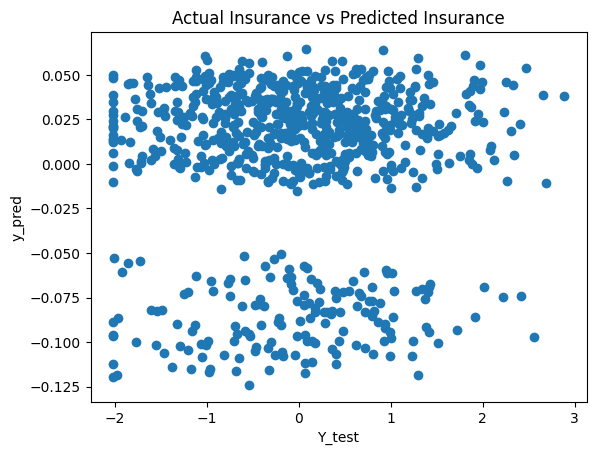

In [103]:
plt.scatter(Y_test['Claim_Amount'],y_pred)
plt.xlabel("Y_test")
plt.ylabel("y_pred")
plt.title("Actual Insurance vs Predicted Insurance")
plt.show()